# Investigating The Office: Viewership, Ratings, and Guest Stars

This notebook explores the episode-level data from *The Office* to understand how audience size and ratings changed over time, which episodes stood out, and whether listed guest stars were associated with different viewership.

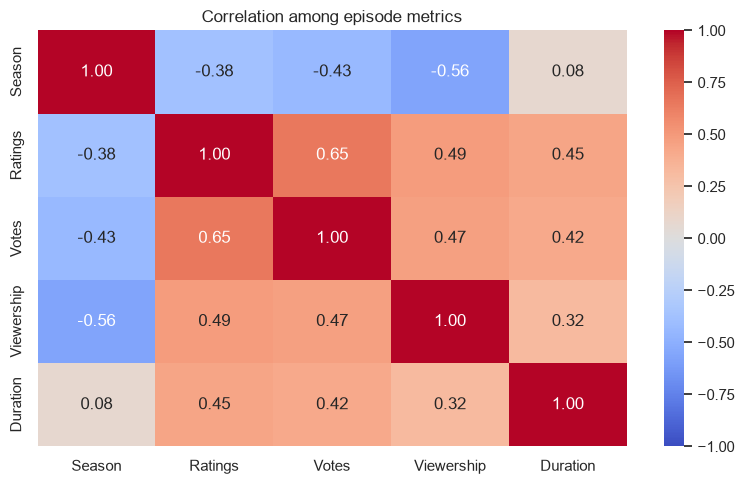

In [27]:
# Examine relationships among key numeric episode metrics
metrics = episodes[['Season', 'Ratings', 'Votes', 'Viewership', 'Duration']]

plt.figure(figsize=(8, 5))
sns.heatmap(
    metrics.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)
plt.title('Correlation among episode metrics')
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 6)

DATA_PATH = Path('the_office_series-selected-columns.csv')
episodes = pd.read_csv(DATA_PATH)
episodes = episodes.drop(columns=[episodes.columns[0]])
episodes['Date'] = pd.to_datetime(episodes['Date'].str.strip(), errors='coerce')
episodes['GuestStars'] = episodes['GuestStars'].fillna('').str.strip()
episodes['has_guest_star'] = episodes['GuestStars'].ne('')
episodes['EpisodeNumber'] = episodes.groupby('Season').cumcount() + 1
episodes.info()
episodes.head()

<class 'pandas.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Season          188 non-null    int64         
 1   EpisodeTitle    188 non-null    str           
 2   About           188 non-null    str           
 3   Ratings         188 non-null    float64       
 4   Votes           188 non-null    int64         
 5   Viewership      188 non-null    float64       
 6   Duration        188 non-null    int64         
 7   Date            188 non-null    datetime64[us]
 8   GuestStars      188 non-null    str           
 9   has_guest_star  188 non-null    bool          
 10  EpisodeNumber   188 non-null    int64         
dtypes: bool(1), datetime64[us](1), float64(2), int64(4), str(3)
memory usage: 15.0 KB


,Season,EpisodeTitle,About,Ratings,Votes,Viewership,Duration,Date,GuestStars,has_guest_star,EpisodeNumber
0,1,Pilot,The premiere episode introduces the boss and s...,7.5,4936,11.2,23,2005-03-24,,False,1
1,1,Diversity Day,Michael's off color remark puts a sensitivity ...,8.3,4801,6.0,23,2005-03-29,,False,2
2,1,Health Care,Michael leaves Dwight in charge of picking the...,7.8,4024,5.8,22,2005-04-05,,False,3
3,1,The Alliance,"Just for a laugh, Jim agrees to an alliance wi...",8.1,3915,5.4,23,2005-04-12,,False,4
4,1,Basketball,Michael and his staff challenge the warehouse ...,8.4,4294,5.0,23,2005-04-19,,False,5


## Data quality and season overview

The source contains one row per episode. Blank guest-star fields are treated as episodes without a listed guest star, while numeric columns are kept in their source units.

In [29]:
summary = episodes.groupby('Season').agg(
    episodes=('EpisodeTitle', 'size'),
    avg_viewership=('Viewership', 'mean'),
    avg_rating=('Ratings', 'mean'),
    guest_star_episodes=('has_guest_star', 'sum')
).round(2)
summary

,episodes,avg_viewership,avg_rating,guest_star_episodes
Season,,,,
1,6,6.37,7.97,1
2,22,8.17,8.44,6
3,23,8.49,8.59,1
4,14,8.55,8.56,1
5,26,8.76,8.49,3
6,26,7.77,8.20,3
7,24,7.31,8.31,5
8,24,5.39,7.60,3
9,23,4.14,7.91,6


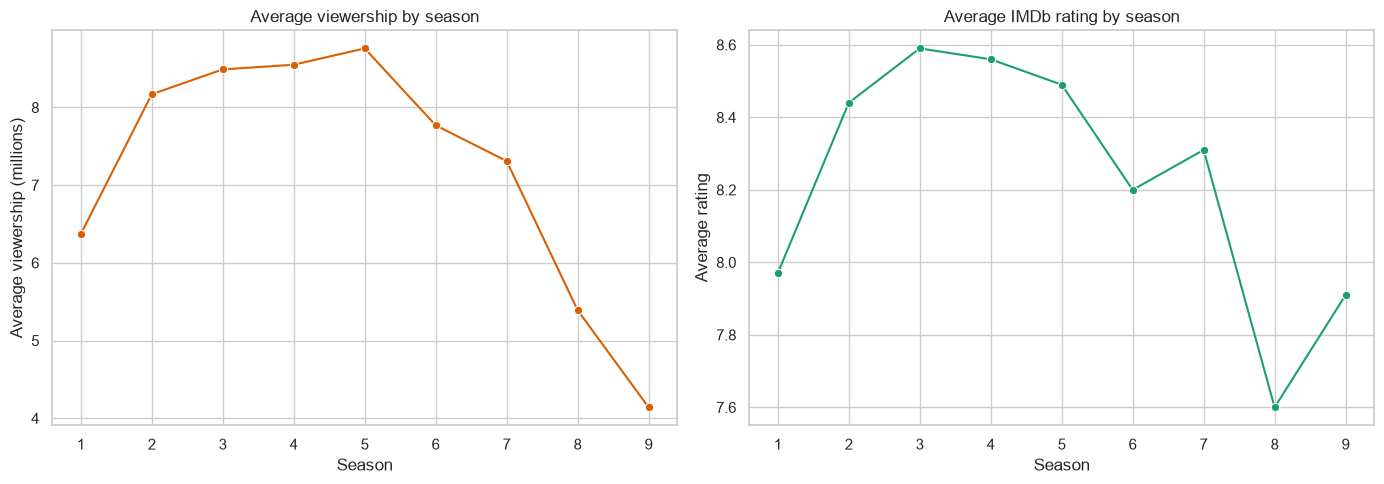

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=summary.reset_index(), x='Season', y='avg_viewership', marker='o', ax=axes[0], color='#d95f02')
axes[0].set(title='Average viewership by season', ylabel='Average viewership (millions)')
sns.lineplot(data=summary.reset_index(), x='Season', y='avg_rating', marker='o', ax=axes[1], color='#1b9e77')
axes[1].set(title='Average IMDb rating by season', ylabel='Average rating')
plt.tight_layout()

## Episode-level trends

Viewership is plotted against the original air date so the trajectory is visible without assuming that seasons had identical lengths.

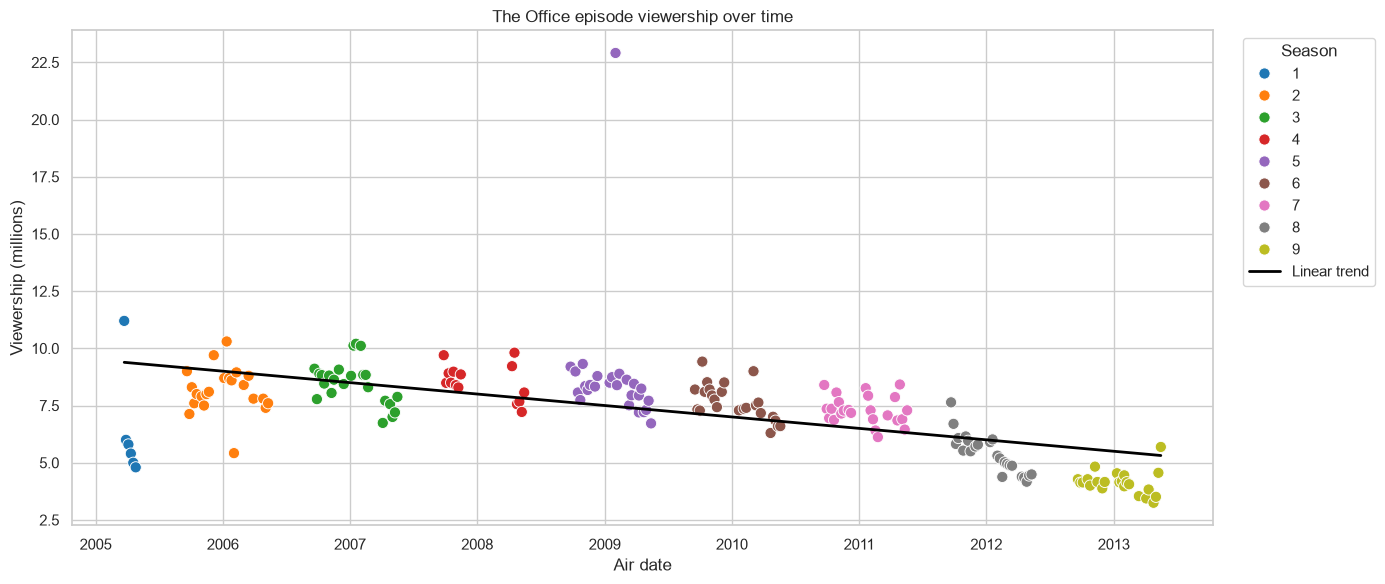

In [31]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(data=episodes, x='Date', y='Viewership', hue='Season', palette='tab10', s=65, ax=ax)
date_ordinals = episodes['Date'].map(pd.Timestamp.toordinal).to_numpy()
trend_coefficients = np.polyfit(date_ordinals, episodes['Viewership'], 1)
trend_dates = pd.date_range(episodes['Date'].min(), episodes['Date'].max(), periods=100)
trend_values = np.polyval(trend_coefficients, trend_dates.map(pd.Timestamp.toordinal))
ax.plot(trend_dates, trend_values, color='black', linewidth=2, label='Linear trend')
ax.set(title='The Office episode viewership over time', xlabel='Air date', ylabel='Viewership (millions)')
ax.legend(title='Season', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

In [32]:
top_viewership = episodes.nlargest(10, 'Viewership')[['Season', 'EpisodeTitle', 'Viewership', 'Ratings', 'GuestStars']]
top_ratings = episodes.nlargest(10, 'Ratings')[['Season', 'EpisodeTitle', 'Ratings', 'Viewership', 'GuestStars']]
print('Top episodes by viewership')
display(top_viewership)
print('Top episodes by rating')
display(top_ratings)

Top episodes by viewership


,Season,EpisodeTitle,Viewership,Ratings,GuestStars
77,5,Stress Relief,22.91,9.7,"Cloris Leachman, Jack Black, Jessica Alba"
0,1,Pilot,11.20,7.5,
17,2,The Injury,10.30,9.1,
40,3,The Return,10.20,8.8,
39,3,Traveling Salesmen,10.12,8.6,
41,3,Ben Franklin,10.11,8.1,
60,4,Chair Model,9.81,8.0,
15,2,Christmas Party,9.70,8.9,
51,4,Fun Run,9.70,8.8,
94,6,Niagara: Part 1,9.42,9.4,


Top episodes by rating


,Season,EpisodeTitle,Ratings,Viewership,GuestStars
137,7,"Goodbye, Michael",9.8,8.42,
187,9,Finale,9.8,5.69,"Joan Cusack, Ed Begley Jr, Rachel Harris, Nanc..."
77,5,Stress Relief,9.7,22.91,"Cloris Leachman, Jack Black, Jessica Alba"
59,4,Dinner Party,9.5,9.22,
186,9,A.A.R.M.,9.5,4.56,
27,2,Casino Night,9.4,7.60,
94,6,Niagara: Part 1,9.4,9.42,
95,6,Niagara: Part 2,9.4,9.42,
132,7,Threat Level Midnight,9.4,6.41,
50,3,The Job,9.3,7.88,


## Guest-star analysis

The comparison below is descriptive rather than causal. A guest-star credit may coincide with a special episode, a different season, or another production factor, so the result should not be interpreted as proof that guest stars caused a change in audience size.

In [33]:
guest_summary = episodes.groupby('has_guest_star').agg(
    episodes=('EpisodeTitle', 'size'),
    avg_viewership=('Viewership', 'mean'),
    median_viewership=('Viewership', 'median'),
    avg_rating=('Ratings', 'mean')
).round(2)
guest_summary.index = guest_summary.index.map({True: 'Listed guest star', False: 'No listed guest star'})
guest_summary

,episodes,avg_viewership,median_viewership,avg_rating
has_guest_star,,,,
No listed guest star,159,7.21,7.51,8.24
Listed guest star,29,7.43,7.60,8.20


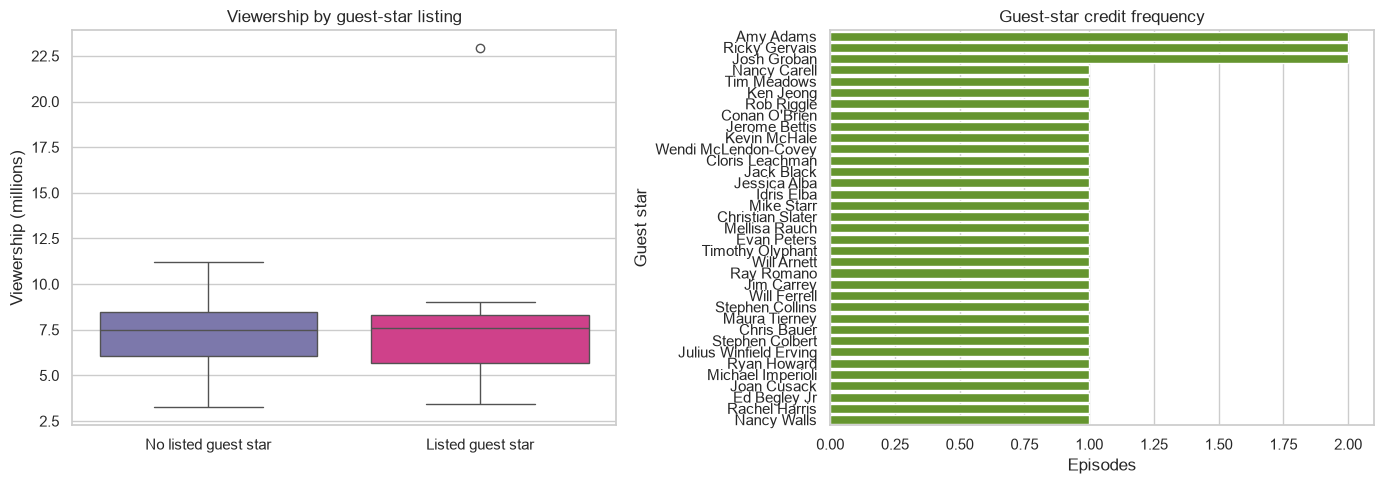

In [34]:
guest_credits = episodes.loc[episodes['has_guest_star'], ['GuestStars']].assign(
    GuestStar=lambda frame: frame['GuestStars'].str.split(', ')
).explode('GuestStar')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=episodes, x='has_guest_star', y='Viewership', hue='has_guest_star', legend=False, ax=axes[0], palette=['#7570b3', '#e7298a'])
axes[0].set(title='Viewership by guest-star listing', xlabel='', ylabel='Viewership (millions)')
axes[0].set_xticks([0, 1], ['No listed guest star', 'Listed guest star'])
star_order = guest_credits['GuestStar'].value_counts().index
sns.countplot(data=guest_credits, y='GuestStar', order=star_order, ax=axes[1], color='#66a61e')
axes[1].set(title='Guest-star credit frequency', xlabel='Episodes', ylabel='Guest star')
plt.tight_layout()

## Findings

- Season-level averages and the time-series plot show whether the audience trend is upward or downward across the run.
- The highest-viewership table identifies the episodes that reached the largest audiences; the highest ratings table captures critical or fan-favorite episodes, which need not be the same episodes.
- Listed guest stars are uncommon in this extract, so their group comparison has limited statistical power. Treat the difference in group averages as an association to investigate, not a causal effect.
- Ratings and viewership measure different outcomes: an episode can be highly rated by viewers who watched it without reaching the largest broadcast audience.

In [35]:
print(f'{len(episodes)} episodes from seasons {episodes.Season.min()}-{episodes.Season.max()}')
print(f"{episodes['has_guest_star'].sum()} episodes have a listed guest star")
print(f"Peak viewership: {episodes.loc[episodes['Viewership'].idxmax(), 'EpisodeTitle']} ({episodes['Viewership'].max():.2f} million)")
print(f"Peak rating: {episodes.loc[episodes['Ratings'].idxmax(), 'EpisodeTitle']} ({episodes['Ratings'].max():.1f})")
print(guest_summary)

188 episodes from seasons 1-9
29 episodes have a listed guest star
Peak viewership: Stress Relief (22.91 million)
Peak rating: Goodbye, Michael (9.8)
                      episodes  avg_viewership  median_viewership  avg_rating
has_guest_star                                                               
No listed guest star       159            7.21               7.51        8.24
Listed guest star           29            7.43               7.60        8.20
